<a href="https://colab.research.google.com/github/Lettify/engenharia-de-prompt-udf/blob/main/Aula%208/Aula08_AutomacaoIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 08
Nome: Gustavo Batista

*Crie um script Python simples para verficar a temperatura de um sistema. Se for maior que 30, exiba um alerta de superaquecimento.*

In [ ]:
temperatura = float(input("Digite a temperatura do sistema: "))

if temperatura > 30:
    print("ALERTA: Superaquecimento detectado!")
else:
    print("Temperatura normal.")

# Missão 1: Automação de Arquivos
*Criar um programa que organize arquivos bagunçados em pastas automaticamente, baseando-se apenas na extensão do arquivo (ex: .pdf, .jpg). Utilize a biblioteca **os** ou **shutil**.*

In [ ]:
import os
import shutil

def organizar_arquivos(diretorio):
    # Verifica se o caminho fornecido realmente existe no sistema
    if not os.path.exists(diretorio):
        print("O diretório especificado não existe.")
        return

    # Itera sobre todos os itens presentes na pasta selecionada
    for arquivo in os.listdir(diretorio):
        caminho_completo = os.path.join(diretorio, arquivo)

        # Garante que estamos mexendo apenas em arquivos, ignorando subpastas
        if os.path.isfile(caminho_completo):
            # Separa o nome do arquivo da sua extensão (ex: .jpg)
            nome, extensao = os.path.splitext(arquivo)
            # Limpa a extensão: remove o ponto e coloca em minúsculas
            extensao = extensao.lower().replace('.', '')

            # Caso o arquivo não tenha extensão, define um nome padrão para a pasta
            if not extensao:
                extensao = 'sem_extensao'

            # Define o caminho da nova pasta baseada na extensão
            pasta_destino = os.path.join(diretorio, extensao)
            # Cria a pasta se ela ainda não existir
            if not os.path.exists(pasta_destino):
                os.makedirs(pasta_destino)

            # Move fisicamente o arquivo da origem para a pasta de destino
            shutil.move(caminho_completo, os.path.join(pasta_destino, arquivo))
            print(f"Movido: {arquivo} -> {extensao}/")

# Mensagem indicando que as funções foram carregadas na memória
print('Script pronto para organizar arquivos!')

### Checklist de sucesso
[X] O script cria pastas caso não existam.\
[X] Arquivos são movidos corretamente.\
[ ] O código executa sem erros de permissão.

# Missão 2: Consulta Simples a APIs
*Desenvolver um script que consulte uma API pública (ViaCEP) e retorne as informações de endereço formatadas de maneira legível.*

In [ ]:
import requests

def consultar_cep(cep):
    # Limpeza: remove pontos e traços que o usuário possa ter digitado
    cep = cep.replace('-', '').replace('.', '').strip()

    # Validação básica: um CEP brasileiro sempre possui 8 dígitos
    if len(cep) != 8:
        print("Erro: O CEP deve conter 8 dígitos.")
        return

    # Monta a URL da API seguindo o formato exigido pelo ViaCEP (JSON)
    url = f'https://viacep.com.br/ws/{cep}/json/'

    try:
        # Faz a requisição HTTP do tipo GET para o servidor
        response = requests.get(url)
        # Verifica se houve erro de conexão ou erro do servidor (ex: 404, 500)
        response.raise_for_status()
        # Converte a resposta formatada em texto/json para um dicionário Python
        dados = response.json()

        # O ViaCEP retorna uma chave 'erro' caso o CEP não exista na base de dados
        if 'erro' in dados:
            print("CEP não encontrado.")
        else:
            # Exibe os dados extraídos do dicionário de forma formatada
            print("\n--- Informações de Endereço ---")
            print(f"CEP: {dados['cep']}")
            print(f"Logradouro: {dados['logradouro']}")
            print(f"Bairro: {dados['bairro']}")
            print(f"Cidade: {dados['localidade']}")
            print(f"Estado: {dados['uf']}")
            print(f"DDD: {dados['ddd']}")
            print("------------------------------")

    except requests.exceptions.RequestException as e:
        # Captura problemas de rede, timeout ou DNS
        print(f"Erro ao consultar a API: {e}")

# Captura a entrada do usuário através do console do Colab
cep_input = input("Digite o CEP para consulta (ex: 01001000): ")
consultar_cep(cep_input)

Digite o CEP para consulta (ex: 01001000): 71070030
DADOS RECEBIDOS:  {'cep': '71070-030', 'logradouro': 'Quadra QE 38 Conjunto C', 'complemento': '', 'unidade': '', 'bairro': 'Guará II', 'localidade': 'Brasília', 'uf': 'DF', 'estado': 'Distrito Federal', 'regiao': 'Centro-Oeste', 'ibge': '5300108', 'gia': '', 'ddd': '61', 'siafi': '9701'}

--- Informações de Endereço ---
CEP: 71070-030
Logradouro: Quadra QE 38 Conjunto C
Bairro: Guará II
Cidade: Brasília
Estado: DF
DDD: 61
------------------------------


### Checklist de sucesso
[X] Integração com a API ViaCEP funcional.\
[X] JSON recebido é formatado e impresso com clareza.\
[X] Erros de conexão ou CEP inválido são tratados sem 'quebrar' o script.

# Missão 3: Sistema de Notificações
*Criar um programa autônomo que dispare alertas (mensagens de alerta no console ou e-mail simulado) unicamente quando uma condição crítica for atingida.* \
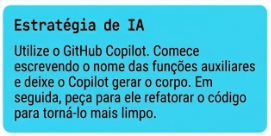

In [5]:
import time
import random

def obter_leitura_sensor():
    """Simula a leitura de um sensor de temperatura gerando um valor aleatório."""
    return random.uniform(20.0, 45.0)

def emitir_alerta(valor, limite):
    """Exibe uma mensagem visual no console quando o limite é ultrapassado."""
    print(f"\n[!!!] ALERTA CRÍTICO DETECTADO [!!!]")
    print(f"Mensagem: A temperatura atingiu {valor:.2f}°C, superando o limite de {limite}°C.")
    print("Enviando notificação para o administrador...\n")

def monitorar_sistema(limite_critico, total_leituras=5, intervalo=1):
    """Função principal de monitoramento que coordena as leituras e alertas."""
    print(f"Iniciando monitoramento... (Limite: {limite_critico}°C)")

    # Loop para realizar o número definido de verificações
    for i in range(1, total_leituras + 1):
        temperatura = obter_leitura_sensor()
        print(f"Leitura {i}: {temperatura:.2f}°C")

        # Verifica se a temperatura atual é maior que o limite permitido
        if temperatura > limite_critico:
            emitir_alerta(temperatura, limite_critico)

        # Pausa a execução por alguns segundos antes da próxima leitura
        time.sleep(intervalo)

# Esta condição garante que o código só execute se o arquivo for rodado diretamente
if __name__ == "__main__":
    # Chamada inicial do sistema definindo o limite de segurança
    monitorar_sistema(limite_critico=35.0)

Iniciando monitoramento... (Limite: 35.0°C)
Leitura 1: 44.10°C

[!!!] ALERTA CRÍTICO DETECTADO [!!!]
Mensagem: A temperatura atingiu 44.10°C, superando o limite de 35.0°C.
Enviando notificação para o administrador...

Leitura 2: 34.55°C
Leitura 3: 37.92°C

[!!!] ALERTA CRÍTICO DETECTADO [!!!]
Mensagem: A temperatura atingiu 37.92°C, superando o limite de 35.0°C.
Enviando notificação para o administrador...

Leitura 4: 38.11°C

[!!!] ALERTA CRÍTICO DETECTADO [!!!]
Mensagem: A temperatura atingiu 38.11°C, superando o limite de 35.0°C.
Enviando notificação para o administrador...

Leitura 5: 43.80°C

[!!!] ALERTA CRÍTICO DETECTADO [!!!]
Mensagem: A temperatura atingiu 43.80°C, superando o limite de 35.0°C.
Enviando notificação para o administrador...



### Checklist de sucesso
[X] Lógica condicional disparando corretamente. \
[X] Código modular (separado em funções). \
[X] Refatoração visíve entre a primeira versão e a versão final.